In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

from torchmetrics.classification import BinaryJaccardIndex
from torchsummary import summary

import imageio
from skimage.morphology import dilation, remove_small_objects, area_closing, area_opening, erosion, disk
from skimage.filters import median, threshold_local, rank, threshold_otsu
import matplotlib.pyplot as plt

In [54]:
from PIL import Image

In [42]:
class SSLNet(nn.Module):
    
    def __init__(self, in_channels, out_channels):
        super(SSLNet, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.mid_level = nn.Sequential(
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(96, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(48, out_channels, kernel_size=2, stride=2, output_padding=0)
        )

    def forward(self, x):
        x1 = self.encoder(x)
        x2 = self.mid_level(x1)
        x3 = self.decoder(x2)

        return x3
    

In [43]:
# /localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t000_ch00_std.png
# /localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t001_ch00_std.png
# /localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t002_ch00_std.png
# /localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t003_ch00_std.png
# /localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t004_ch00_std.png

import imageio

filenames = [f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t0{x:02d}_ch00_std.png' for x in range(100)]

arrays = [imageio.imread(file_path) for file_path in filenames]

in_stacks = [arrays[i:i+4] for i in range(0, len(arrays), 5) if i + 4 <= len(arrays)]

mask_stacks = [arrays[i] for i in range(4, len(arrays), 5)]

In [44]:
import numpy as np
np.array(in_stacks).shape

(20, 4, 128, 128)

In [45]:
np.array(mask_stacks).shape

(20, 128, 128)

In [46]:
mask_stacks = np.expand_dims(mask_stacks, 1)

In [47]:
mask_stacks.shape

(20, 1, 128, 128)

In [48]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

class SSLDataset(Dataset):
    def __init__(self, in_stacks, mask_stacks, transform=None):
        self.in_stacks = in_stacks
        self.mask_stacks = mask_stacks
        self.transform = transform

    def __len__(self):
        return len(self.in_stacks)

    def __getitem__(self, idx):
        in_stack = torch.Tensor(self.in_stacks[idx])  # Assuming data_stacks is a numpy array
        mask_stack = torch.Tensor(self.mask_stacks[idx])  # Assuming mask_stacks is a numpy array

        return in_stack, mask_stack

transform = transforms.Compose([
    transforms.ToTensor()
])

# Create the custom dataset
dataset = SSLDataset(in_stacks, mask_stacks, )

# Create the data loader
batch_size = 4  # Adjust the batch size as needed
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Now you can iterate over the data loader to get batches of data
# for batch in data_loader:
#     data_batch = batch['input']  # Access the data batch
#     mask_batch = batch['mask']  # Access the mask batch

    # Your training/validation loop here
    # ...

# for i, (img, mask) in enumerate(data_loader):
#     plt.imshow(img[0][1])

In [52]:
in_channels = 4
out_channels = 1

model = SSLNet(in_channels, out_channels)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training loop
num_epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    for inputs, masks in train_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
#         outputs = (torch.sigmoid(outputs) > 0.5).float()
        loss = criterion(outputs, masks)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print the training loss for each epoch
    print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {loss.item()}")
    
# jacc = BinaryJaccardIndex().to(device)
# total_iou = 0
    
# # Testing loop
# model.eval()
# test_loss = 0.0
# with torch.no_grad():
#     for inputs, masks in test_loader:
#         inputs, masks = inputs.to(device), masks.to(device)

#         # Forward pass
#         outputs = model(inputs)
#         loss = criterion(outputs, masks)
#         test_loss += loss.item()
        
#         batch_iou = jacc(outputs, masks).item()
#         total_iou += batch_iou

# # Calculate and print the average test loss
# average_test_loss = test_loss / len(test_loader)
# print(f"Average Test Loss: {average_test_loss}")

# print(f"Mean IoU: {total_iou/ len(test_loader)}")


Epoch [1/50], Training Loss: 1130.049560546875
Epoch [2/50], Training Loss: 832.8277587890625
Epoch [3/50], Training Loss: 743.2554321289062
Epoch [4/50], Training Loss: 478.80401611328125
Epoch [5/50], Training Loss: 357.06439208984375
Epoch [6/50], Training Loss: 384.8919677734375
Epoch [7/50], Training Loss: 274.25787353515625
Epoch [8/50], Training Loss: 265.2950439453125
Epoch [9/50], Training Loss: 228.80392456054688
Epoch [10/50], Training Loss: 238.00076293945312
Epoch [11/50], Training Loss: 197.72174072265625
Epoch [12/50], Training Loss: 214.79615783691406
Epoch [13/50], Training Loss: 186.78207397460938
Epoch [14/50], Training Loss: 184.0157928466797
Epoch [15/50], Training Loss: 192.5878143310547
Epoch [16/50], Training Loss: 161.26560974121094
Epoch [17/50], Training Loss: 144.15341186523438
Epoch [18/50], Training Loss: 156.7470245361328
Epoch [19/50], Training Loss: 153.7315216064453
Epoch [20/50], Training Loss: 157.7957763671875
Epoch [21/50], Training Loss: 146.40037

In [58]:
np.array(in_stacks[0]).shape

(4, 128, 128)

In [62]:
ip = torch.Tensor(in_stacks[0])

# image = Image.fromarray(ip)
# # image = Image.open(image_path)#.convert('L')  # Convert to grayscale
# transform = transforms.Compose([
# #     transforms.Resize((128, 128)),
#     transforms.ToTensor(),
# ])

# image = transform(image)
# image = image.unsqueeze(0)  # Add batch dimension
ip = ip.unsqueeze(0)

# Forward pass through the model
model.eval()
with torch.no_grad():
    output = model(ip.to(device))

# Convert the output to probabilities by applying the sigmoid activation
output_probs = torch.sigmoid(output)
# type(output_probs)

# Convert tensors to numpy arrays for visualization
image_np = ip.squeeze().numpy()
output_probs_np = output_probs.cpu().squeeze().numpy()

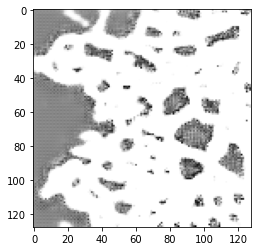

In [65]:
plt.imshow(output_probs_np, cmap='gray')